# 8. Iron

Iron is the most abundant redox-active metal on Earth and the one where the
solid phases matter most. Its aqueous chemistry is a footnote to its mineral
chemistry: what a cell actually respires is usually a surface, and which
surface depends on pH, on how much carbonate and sulfide are about, and on
how much iron is dissolved.

That makes iron the element where the three diagrams disagree most
interestingly, and where knowing what each one is *for* matters.

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.figures import (
    frost_diagram,
    latimer_diagram,
    plot_frost,
    plot_latimer,
    plot_pourbaix,
)
from microbial_thermo.figures.basis import element_series
from microbial_thermo.figures.pourbaix import pourbaix_field

warnings.filterwarnings("ignore", category=UserWarning)

## The ladder, and what is not allowed on it

In [2]:
ladder = latimer_diagram("Fe", pH=7.0)
ladder.to_frame()

,oxidized,reduced,n electrons,E (V),dG (kJ/mol element),half reaction
0,Hematite,Magnetite,0.333333,-0.254319,8.179342,Hematite + 1/3 H+ + 1/3 e- -> Magnetite + 1/6 H2O
1,Magnetite,Fe++,0.666667,-0.577043,37.117425,Magnetite + 8/3 H+ + 2/3 e- -> Fe++ + 4/3 H2O
2,Fe++,Fe,2.000000,-0.474206,91.507851,Fe++ + 2 e- -> Fe


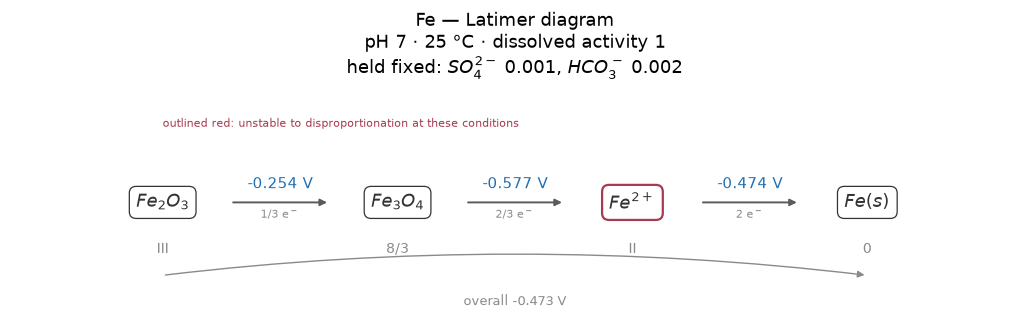

In [3]:
plot_latimer("Fe", diagram=ladder)
plt.show()

Magnetite sits between Fe(III) and Fe(II) at **+8/3**, which is not a
typo: Fe₃O₄ is one ferrous iron and two ferric, and the mean state is
exactly 8/3. The fractional electron counts on the arrows follow from it.

Two iron minerals were offered and refused a rung, and the reason is worth
reading:

In [4]:
for name, why in ladder.excluded:
    print(f"{name}: {why}\n")

Siderite: its electron count is measured against C (as HCO3-), so it is not Fe's oxidation state

Pyrite: its electron count is measured against S (as SO4--), so it is not Fe's oxidation state



**Pyrite is the case that forces the rule.** FeS₂ is iron(II) with sulfur at
−I, a disulfide. Our basis accounts for sulfur as sulfate, so forming pyrite
from Fe(0) takes twelve electrons per iron — a real number about a real
reaction, and emphatically not iron's oxidation state. A rung on a Latimer
or Frost diagram must be a species whose electron count *is* a state, so
pyrite is refused.

Siderite is refused with it, although FeCO₃ really is Fe(II) and would have
been right. Telling those two apart mechanically needs an oxidation-state
assignment independent of the decomposition, and the one this library has
refuses metal sulfides outright — which is precisely the case in question. A
rule that is never wrong beats a rule that is sometimes wrong and silent
about it. Nothing is lost: siderite is Fe(II), and Fe²⁺ already holds that
rung.

Both are back on the Eh–pH diagram below, which is where a siderite or
pyrite field belongs.

## What is stable, and why unit activity is the wrong question for iron

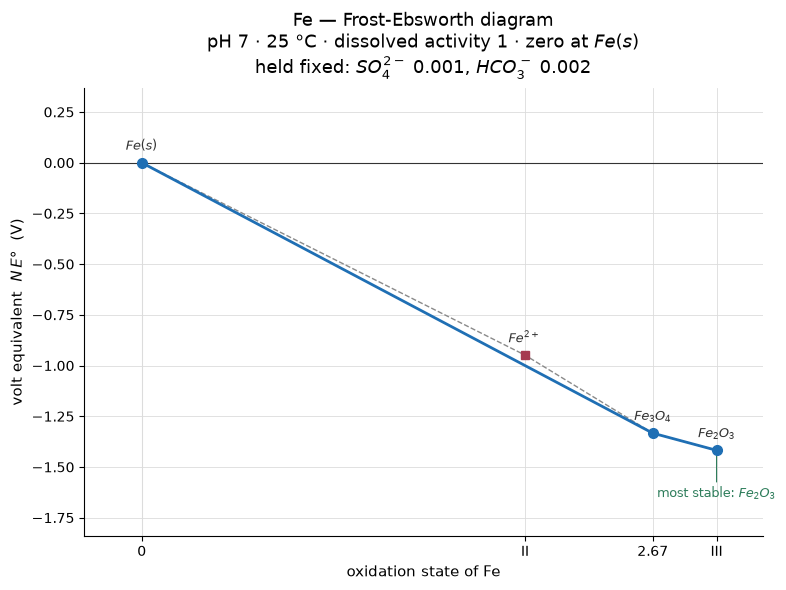

In [5]:
plot_frost("Fe", pH=7.0, activity=1.0)
plt.show()

In [6]:
unit = frost_diagram("Fe", pH=7.0, activity=1.0)
for event in unit.disproportionation():
    print(event)

Fe++ -> 0.75 Magnetite + 0.25 Fe  (-5.0 kJ/mol Fe++)


At unit activity the diagram claims Fe²⁺ disproportionates into magnetite
and iron metal. That is arithmetically correct and physically absurd: a 1 M
ferrous solution at pH 7 is supersaturated with respect to essentially every
iron mineral there is. It is not a condition; it is a convention.

Draw it at an activity a groundwater might actually have:

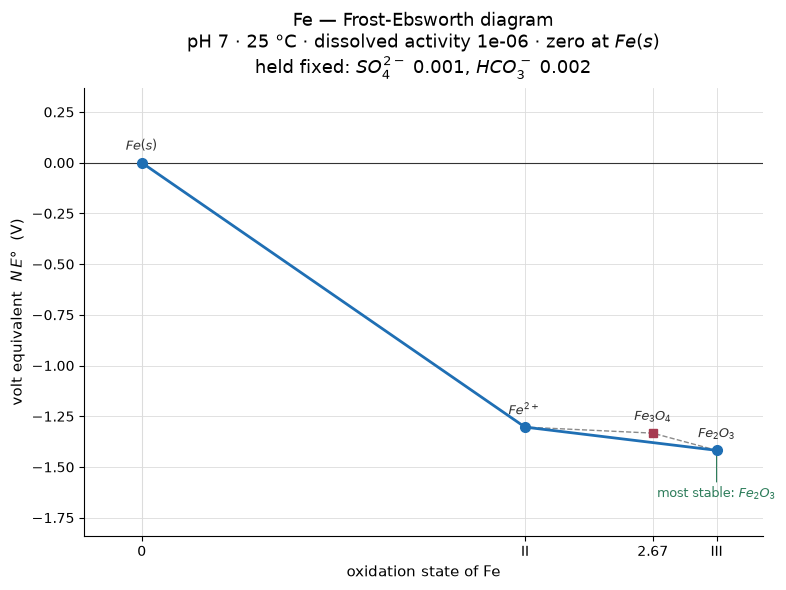

In [7]:
plot_frost("Fe", pH=7.0, activity=1e-6)
plt.show()

In [8]:
real = frost_diagram("Fe", pH=7.0, activity=1e-6)
print("on the hull:", [p.backend for p in real.stable])
for event in real.disproportionation():
    print(event)

on the hull: ['Fe', 'Fe++', 'Hematite']
Magnetite -> 0.667 Hematite + 0.333 Fe++  (-4.5 kJ/mol Magnetite)


Now Fe²⁺ is stable and **magnetite** is the marginal phase, unstable to
hematite plus Fe²⁺ by a few kJ per mole. That is about right: magnetite's
stability field is genuinely narrow and genuinely sensitive to how much
ferrous iron is in solution. Watch it move:

In [9]:
for activity in (1e-2, 1e-4, 1e-6, 1e-8):
    diagram = frost_diagram("Fe", pH=7.0, activity=activity)
    off = [f"{e.species} ({e.delta_g:+.1f} kJ/mol)" for e in diagram.disproportionation()]
    print(f"activity {activity:.0e}: hull {[p.backend for p in diagram.stable]}"
          f"{'  off-hull: ' + ', '.join(off) if off else ''}")

activity 1e-02: hull ['Fe', 'Fe++', 'Magnetite', 'Hematite']
activity 1e-04: hull ['Fe', 'Fe++', 'Hematite']  off-hull: Magnetite (-0.7 kJ/mol)
activity 1e-06: hull ['Fe', 'Fe++', 'Hematite']  off-hull: Magnetite (-4.5 kJ/mol)
activity 1e-08: hull ['Fe', 'Fe++', 'Hematite']  off-hull: Magnetite (-8.3 kJ/mol)


## Where each form lives

This is the diagram iron actually needs, because it is the one that can hold
a carbonate and a sulfide field at the same time.

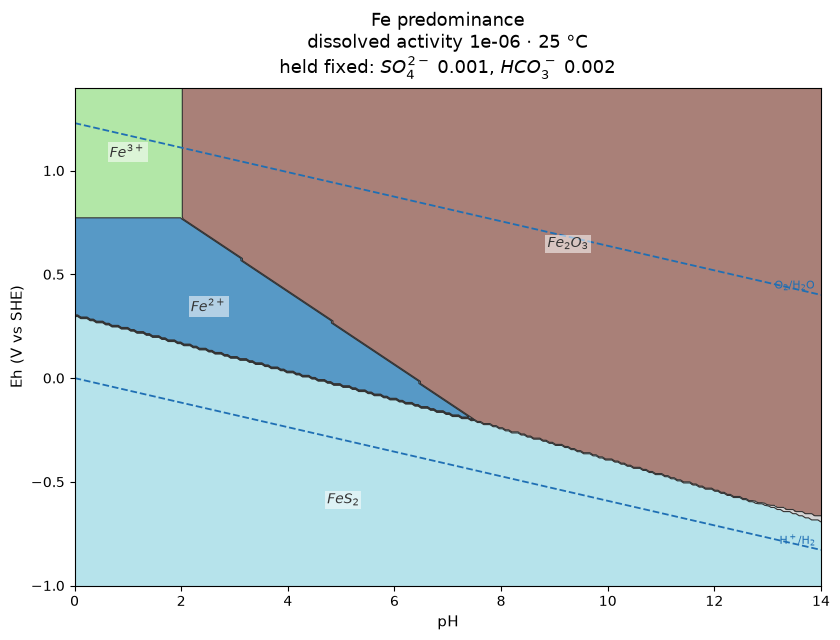

In [10]:
plot_pourbaix("Fe", figsize=(8.5, 6.5))
plt.show()

The pyrite field at the bottom exists **only because there is sulfide**, at
a concentration stated in the figure title. Change that number and the field
changes size; set it to zero and the field disappears. It is a modelling
input, not a property of iron:

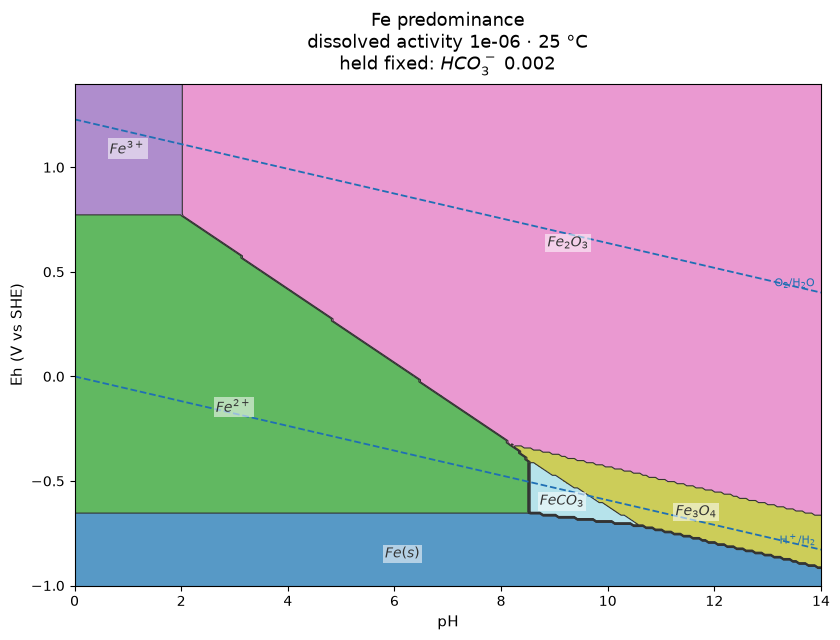

In [11]:
plot_pourbaix("Fe", fixed={"S": ("SO4-2", 0), "C": ("HCO3-", 2e-3)}, figsize=(8.5, 6.5))
plt.show()

Pyrite is gone, and the subtitle no longer claims sulfate is held fixed —
nothing on the figure contains sulfur, so there is nothing to hold.

What moved into the space it held is worth measuring rather than guessing:

In [12]:
import collections

with_sulfide = pourbaix_field("Fe", fixed={"S": ("SO4-2", 1e-6), "C": ("HCO3-", 2e-3)})
without = pourbaix_field("Fe", fixed={"S": ("SO4-2", 0), "C": ("HCO3-", 2e-3)})

was_pyrite = with_sulfide.winner == with_sulfide.species.index("Pyrite")
print(f"pyrite held {was_pyrite.mean():.1%} of the panel; without sulfide that area is now")
counts = collections.Counter(without.species[int(i)] for i in without.winner[was_pyrite])
for name, count in counts.most_common():
    print(f"   {name:12s} {count / was_pyrite.sum():5.1%}")

pyrite held 33.1% of the panel; without sulfide that area is now
   Fe++         48.7%
   Fe           38.6%
   Magnetite     9.8%
   Siderite      2.3%
   Hematite      0.6%


**Siderite appears, and takes almost none of it.** Nearly half goes back to
dissolved Fe²⁺ and most of the rest to iron metal below the water line;
carbonate picks up about two percent.

That is the useful result, and it is the opposite of what "remove the
sulfide and the carbonate takes over" would predict. Sulfide is a far
stronger sink for ferrous iron than carbonate is — which is why pyrite, not
siderite, is the mineral that ends up holding iron in anoxic marine
sediment, and why siderite is a freshwater mineral, where there is
carbonate about and very little sulfate to reduce.

An activity of exactly zero means *the element is absent*, and every species
needing it is dropped by name rather than evaluated at `log(0)`:

In [13]:
series = element_series("Fe", fixed={"S": ("SO4-2", 0), "C": ("HCO3-", 2e-3)})
for name, why in series.skipped:
    print(f"{name}: {why}")

Pyrite: needs S, which is fixed at zero activity and so is absent


## Who lives on each step

In [14]:
conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
iron = [
    "iron_oxidation_oxygen",
    "nitrate_dependent_iron_oxidation",
    "iron_carbon_fixation",
    "ferrihydrite_reduction_acetate",
    "goethite_reduction_hydrogen",
]
table = mt.energy_table(conditions).set_index("name")
table.loc[iron][["label", "dG per e- (kJ/mol)", "reaction"]]

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


,label,dG per e- (kJ/mol),reaction
name,,,
iron_oxidation_oxygen,Iron(II) oxidation with oxygen,-125.320290,2 Fe++ + 3 H2O + 1/2 O2(aq) -> 2 Goethite + 4 H+
nitrate_dependent_iron_oxidation,Nitrate-dependent iron(II) oxidation,-112.911191,2 Fe++ + 14/5 H2O + 2/5 NO3- -> 2 Goethite + 1...
iron_carbon_fixation,Carbon fixation driven by iron(II) oxidation (...,25.812979,2 Fe++ + 11/2 H2O + 1/2 CO2(aq) -> 2 Fe(OH)3 +...
ferrihydrite_reduction_acetate,Ferrihydrite reduction with acetate,-12.675261,1/4 Acetate + 17/4 H+ + 2 Fe(OH)3 -> 1/2 CO2(a...
goethite_reduction_hydrogen,Goethite reduction with hydrogen,2.595202,4 H+ + H2(g) + 2 Goethite -> 2 Fe++ + 4 H2O


Three ways to oxidise ferrous iron, and they are a potted history of when
each was believed.

**With oxygen** is the obvious one and pays best. It is also fast
abiotically at pH 7, which is why iron-oxidising bacteria are pushed to
microaerophilic interfaces — they are racing the chemistry, not exploiting
an untouched substrate.

**With nitrate** works in sediment that never sees oxygen, and explains
ferric oxides in places where the textbook said they could not form.

**With light** pays nothing at all — it is *endergonic*, at about
+26 kJ/mol e⁻ — because it is not a respiration. Photoferrotrophs use
ferrous iron as an electron donor for CO₂ fixation and pay the difference
with photons. That is the cost side of the ledger, and notebook `photoFe`
works out how many photons it takes.

The last row of the table is the one that should look wrong:

In [15]:
print(table.loc["goethite_reduction_hydrogen", ["dG per e- (kJ/mol)", "reaction"]].to_string())

dG per e- (kJ/mol)                                       2.595202
reaction              4 H+ + H2(g) + 2 Goethite -> 2 Fe++ + 4 H2O


**Positive.** Reducing goethite with hydrogen does not pay at pH 7 and
standard state — yet iron reduction is one of the major respirations in
freshwater sediment. Both things are true, and the resolution is in what
"standard state" fixes:

* Goethite is the *crystalline* oxide. Iron reducers work on poorly
  ordered ferrihydrite, which is much less stable and therefore a much
  better oxidant — the `ferrihydrite_reduction_acetate` row above.
* Standard state puts Fe²⁺ at unit activity. Real porewater is micromolar,
  and every order of magnitude of Fe²⁺ removed makes the reduction more
  favourable.

So "iron reduction" is not one reaction with one energy; it is a family
spanning tens of kJ/mol depending on which mineral and which porewater. The
`fixed=` and `activity=` arguments used throughout this notebook are how
that gets said precisely instead of hand-waved.

## One thing worth taking away

The three diagrams are not three views of one truth; they answer three
questions, and iron is where the difference shows.

* The **Latimer** ladder asks what a one-step reduction is worth. It needs
  species whose oxidation state is meaningful, so it excludes pyrite.
* The **Frost** curve asks which forms survive being left alone. It depends
  on activity so strongly that the unit-activity version — the one in every
  textbook — describes a solution that cannot exist.
* The **Eh–pH** field asks what is actually present. It is the only one that
  can hold other elements at stated concentrations, and therefore the only
  one that can say anything about siderite or pyrite.

Asking the wrong one of the three is the most common way to get a confident
wrong answer about iron.